In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('ecommerce_data.csv')
print(df.head())

   user id                        product id Interaction type  \
0      1.0  4c69b61db1fc16e7013b43fc926e502d         purchase   
1      2.0  66d49bbed043f5be260fa9f7fbff5957             view   
2      3.0  2c55cae269aebf53838484b0d7dd931a             like   
3      4.0  18018b6bc416dab347b1b7db79994afa             view   
4      5.0  e04b990e95bf73bbe6a3fa09785d7cd0             like   

        Time stamp  Unnamed: 4  
0  10/10/2023 8:00         NaN  
1  11/10/2023 8:00         NaN  
2  12/10/2023 8:00         NaN  
3  13/10/2023 8:00         NaN  
4  14/10/2023 8:00         NaN  


In [3]:
if 'Unnamed: 4' in df.columns:
    df = df.drop(columns=['Unnamed: 4'])

df['Time stamp'] = pd.to_datetime(
    df['Time stamp'],
    format='%d/%m/%Y %H:%M'
)

In [4]:
df['jam'] = df['Time stamp'].dt.hour
df['tanggal'] = df['Time stamp'].dt.day
df['bulan'] = df['Time stamp'].dt.month
df['hari_dalam_minggu'] = df['Time stamp'].dt.day_name()

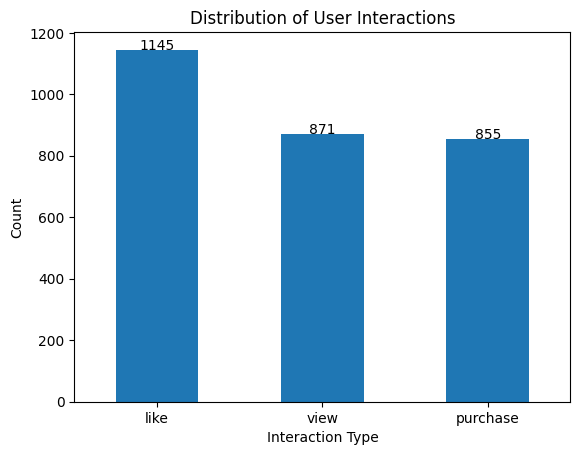

In [5]:
interaction_counts = df['Interaction type'].value_counts()

plt.figure()
ax = interaction_counts.plot(kind='bar')
plt.title('Distribution of User Interactions')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

for i, v in enumerate(interaction_counts):
    ax.text(i, v, str(v), ha='center')

plt.savefig('interaction_distribution.png')

plt.show()

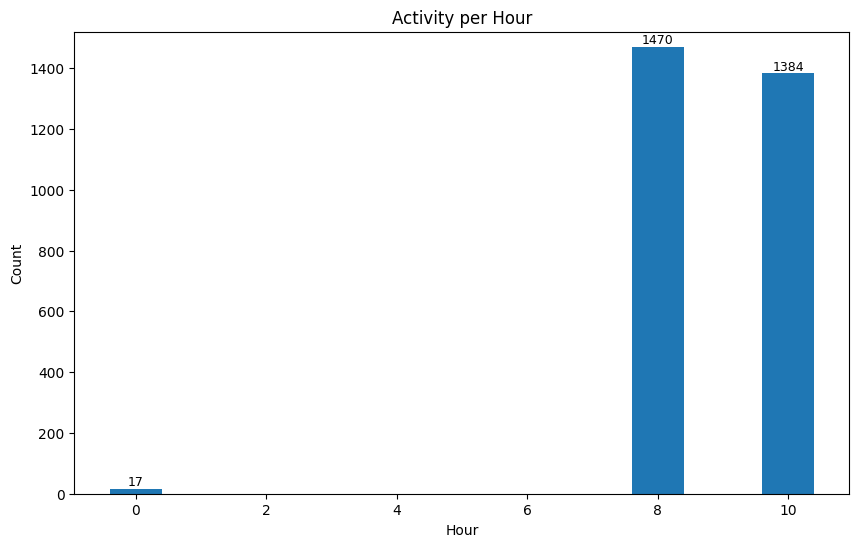

In [17]:
jam_counts = df.groupby('jam')['Interaction type'].count()

plt.figure(figsize=(10,6))
bars = plt.bar(jam_counts.index, jam_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha='center',
        fontsize=9
    )

plt.ylim(0, max(jam_counts.values) + 50)

plt.title('Activity per Hour')
plt.xlabel('Hour')
plt.ylabel('Count')

plt.savefig('activity_per_hour.png')

plt.show()

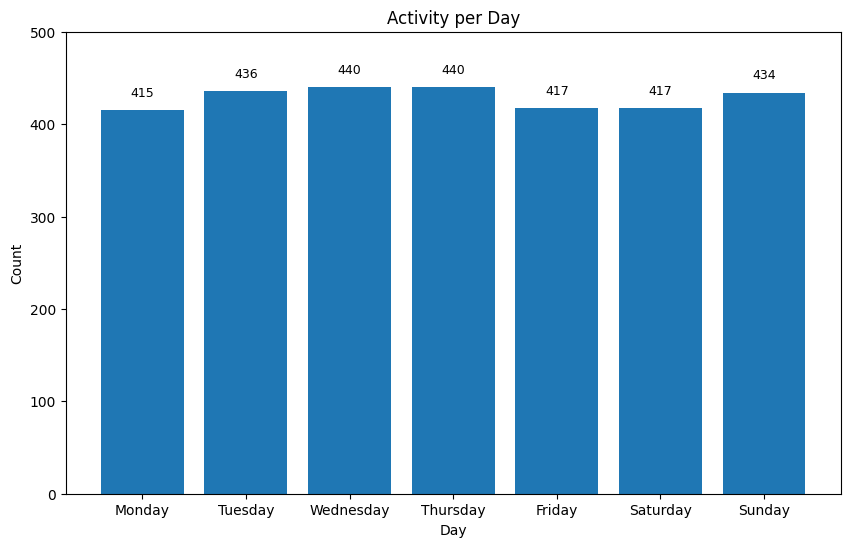

In [18]:
hari_counts = df['hari_dalam_minggu'].value_counts()

urutan = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
hari_counts = hari_counts.reindex(urutan)

plt.figure(figsize=(10,6))

bars = plt.bar(hari_counts.index, hari_counts.values)


for i, v in enumerate(hari_counts.values):
    plt.text(i, v + 15, str(v), ha='center', fontsize=9)


plt.ylim(0, max(hari_counts.values) + 60)

plt.title('Activity per Day')
plt.xlabel('Day')
plt.ylabel('Count')

plt.savefig('activity_per_day.png')
plt.show()

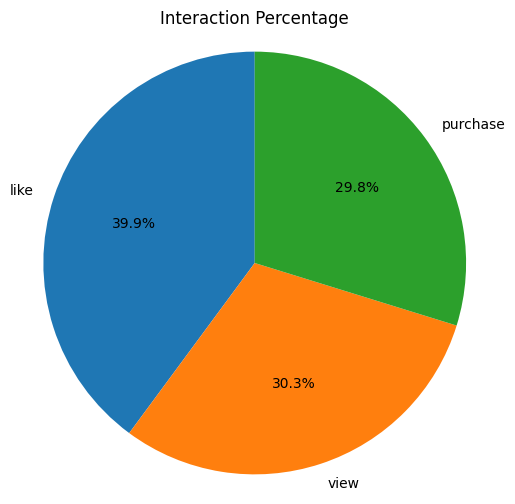

In [24]:
interaction_pct = df['Interaction type'].value_counts(normalize=True) * 100
plt.figure(figsize=(6,6))
plt.pie(
    interaction_pct,
    labels=interaction_pct.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Interaction Percentage')

plt.axis('equal')

plt.savefig('interaction_percentage.png')

plt.show()

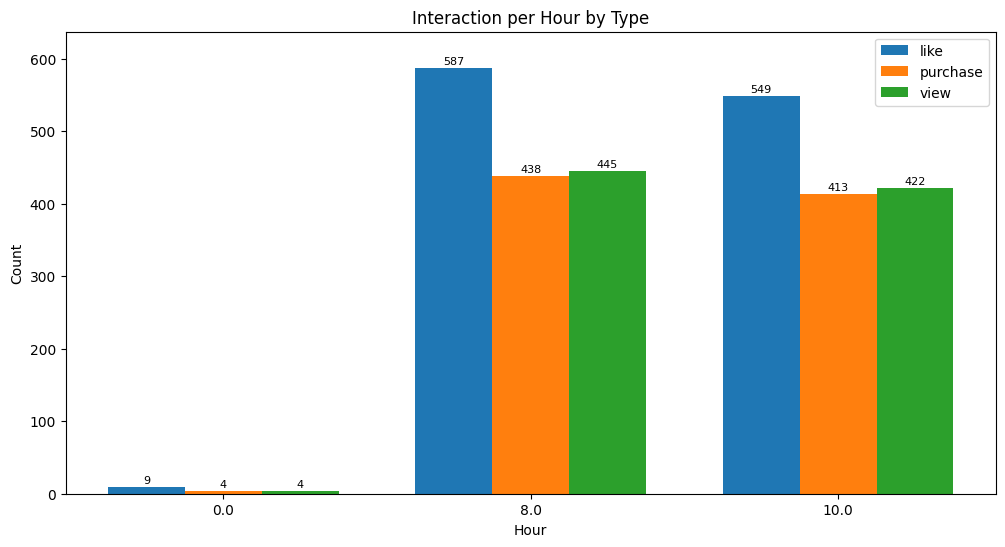

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# group data
jam_interaction = df.groupby(['jam','Interaction type']).size().unstack(fill_value=0)

# ambil data
jam = jam_interaction.index
interaction_types = jam_interaction.columns

x = np.arange(len(jam))  # posisi X
width = 0.25  # lebar bar

plt.figure(figsize=(12,6))

# plot tiap interaction type
for i, interaction in enumerate(interaction_types):
    plt.bar(
        x + i*width,
        jam_interaction[interaction],
        width,
        label=interaction
    )

    # label data
    for j, v in enumerate(jam_interaction[interaction]):
        plt.text(
            x[j] + i*width,
            v + 5,
            str(v),
            ha='center',
            fontsize=8
        )

# atur posisi x-axis
plt.xticks(x + width, jam)

plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('Interaction per Hour by Type')
plt.legend()

# kasih ruang atas
plt.ylim(0, jam_interaction.values.max() + 50)

# save
plt.savefig('%jam_interaction.png')

plt.show()